In [72]:
## Import packages

import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from astropy.io import ascii
print('\nSuccessfully loaded packages')


## CONFIG

# Specify the path to the data we're working with
config = {
    'file' : '/home/laufreder/nthu/pink-starfruit/data/sam-jwst-deep-real0-z4.0-4.5-RA-Dec-F184.csv',
    'zrange' : [4.0, 4.5], # [min, max]
    'thresh_var' : 'Roman_F184', # input the column name of the variable to visualize on top of RA/Dec plot
    'thresh_val' : [24.5, 'LT'] # [limit, less than (LT) greater than (GT) equal (EQ)]
}


Successfully loaded packages


In [73]:
# Load in the variable names...
header_data = ascii.read(
    table= config['file'], 
    format='csv',
    data_end=0,
    )

col_names = header_data.colnames
print('\nSuccessfully loaded dataframe header')
print(f"\n# of columns = {len(col_names)}")
print(col_names)


Successfully loaded dataframe header

# of columns = 5
['ra', 'dec', 'Roman_F184', 'z_nopec', 'redshift']


In [74]:
# Read in ALL of the light-cone data
data = pd.read_csv(config['file'], comment='#', names=col_names)
print("# of datapoints:", len(data))

# of datapoints: 106349


In [75]:
data.loc[0, 'z_nopec']

'z_nopec'

In [76]:
## Making a scatter plot of locations of galaxies on the sky

# Pull values from the config
lim = config['thresh_val'][0]
cond = config['thresh_val'][1] # condition relating the the threshold value (greater than, less than, etc.)
z_min = config['zrange'][0]
z_max = config['zrange'][1]
selection = [] # indices of rows that satisfy criteria below

print(lim, cond, z_min, z_max)

for i in range(1,len(data)): 
    thresh_var = np.float64(data.loc[i, config['thresh_var']])
    z_nopec = np.float64(data.loc[i, 'z_nopec'])

    if cond == 'LT':
        if (thresh_var < lim) and (z_min < z_nopec < z_max):
            selection.append(i)

    elif cond == 'GT':
        if (thresh_var > lim) and (z_min < z_nopec < z_max):
            selection.append(i)

    elif cond == 'EQ':
        if (thresh_var == lim) and (z_min < z_nopec < z_max):
            selection.append(i)   

print(len(selection))

24.5 LT 4.0 4.5
232


In [77]:
# Make a list containing the coordinates of these rows
ra_vals = []
dec_vals = []

# Make a list for the stellar mass of these rows
thresh_vals = []

for i in selection:
    ra = np.float64(data.loc[i, 'ra'])
    dec = np.float64(data.loc[i, 'dec'])
    var = np.float64(data.loc[i, config['thresh_var']])
    ra_vals.append(ra)
    dec_vals.append(dec)
    thresh_vals.append(var)

# sanity check
print(len(ra_vals), len(dec_vals), len(thresh_vals), 'all should be SAME')

232 232 232 all should be SAME


In [78]:
# The RA value range is past 0deg down to 359 something something deg, so we're going to adjust it 
print('before')
print(min(dec_vals), max(dec_vals), np.mean(dec_vals))
print(min(ra_vals), max(ra_vals), np.mean(ra_vals))

for i in range(len(ra_vals)):
    if ra_vals[i] > 2:
        ra_vals[i] -= 360

print('after')
print(min(dec_vals), max(dec_vals), np.mean(dec_vals))
print(min(ra_vals), max(ra_vals), np.mean(ra_vals))


before
-27.916365 -27.734108 -27.822470745689653
53.099205 53.3236 53.206533125
after
-27.916365 -27.734108 -27.822470745689653
-306.900795 -306.6764 -306.79346687500004


In [79]:
print(f"Initial variable dist: \nmin: {np.min(thresh_vals)} \nmax: {np.max(thresh_vals)} \nstd: {np.std(thresh_vals)} \navg: {np.mean(thresh_vals)}")

norm_vals = (thresh_vals - np.mean(thresh_vals))/np.std(thresh_vals)

print(f"\nNormed variable dist: \nmin: {np.min(norm_vals)} \nmax: {np.max(norm_vals)} \nstd: {np.std(norm_vals)} \navg: {np.mean(norm_vals)}")

for i in range(len(norm_vals)):
    if norm_vals[i] < 0.1:
        norm_vals[i] = 0.1

print(f"\nNormed+cutoff variable dist: \nmin: {np.min(norm_vals)} \nmax: {np.max(norm_vals)} \nstd: {np.std(norm_vals)} \navg: {np.mean(norm_vals)}")

size_vals = 1/(norm_vals)
print(f"\nPt size dist: \nmin: {np.min(size_vals)} \nmax: {np.max(size_vals)} \nstd: {np.std(size_vals)} \navg: {np.mean(size_vals)}")



Initial variable dist: 
min: 21.79299 
max: 24.496021 
std: 0.6526705840693567 
avg: 23.627523146551727

Normed variable dist: 
min: -2.810810217787874 
max: 1.3306833104584652 
std: 1.0000000000000002 
avg: -4.586369598279095e-15

Normed+cutoff variable dist: 
min: 0.1 
max: 1.3306833104584652 
std: 0.43547025304996223 
avg: 0.4679854154884691

Pt size dist: 
min: 0.7514936064355284 
max: 10.0 
std: 4.278435141822184 
avg: 5.773216552369055


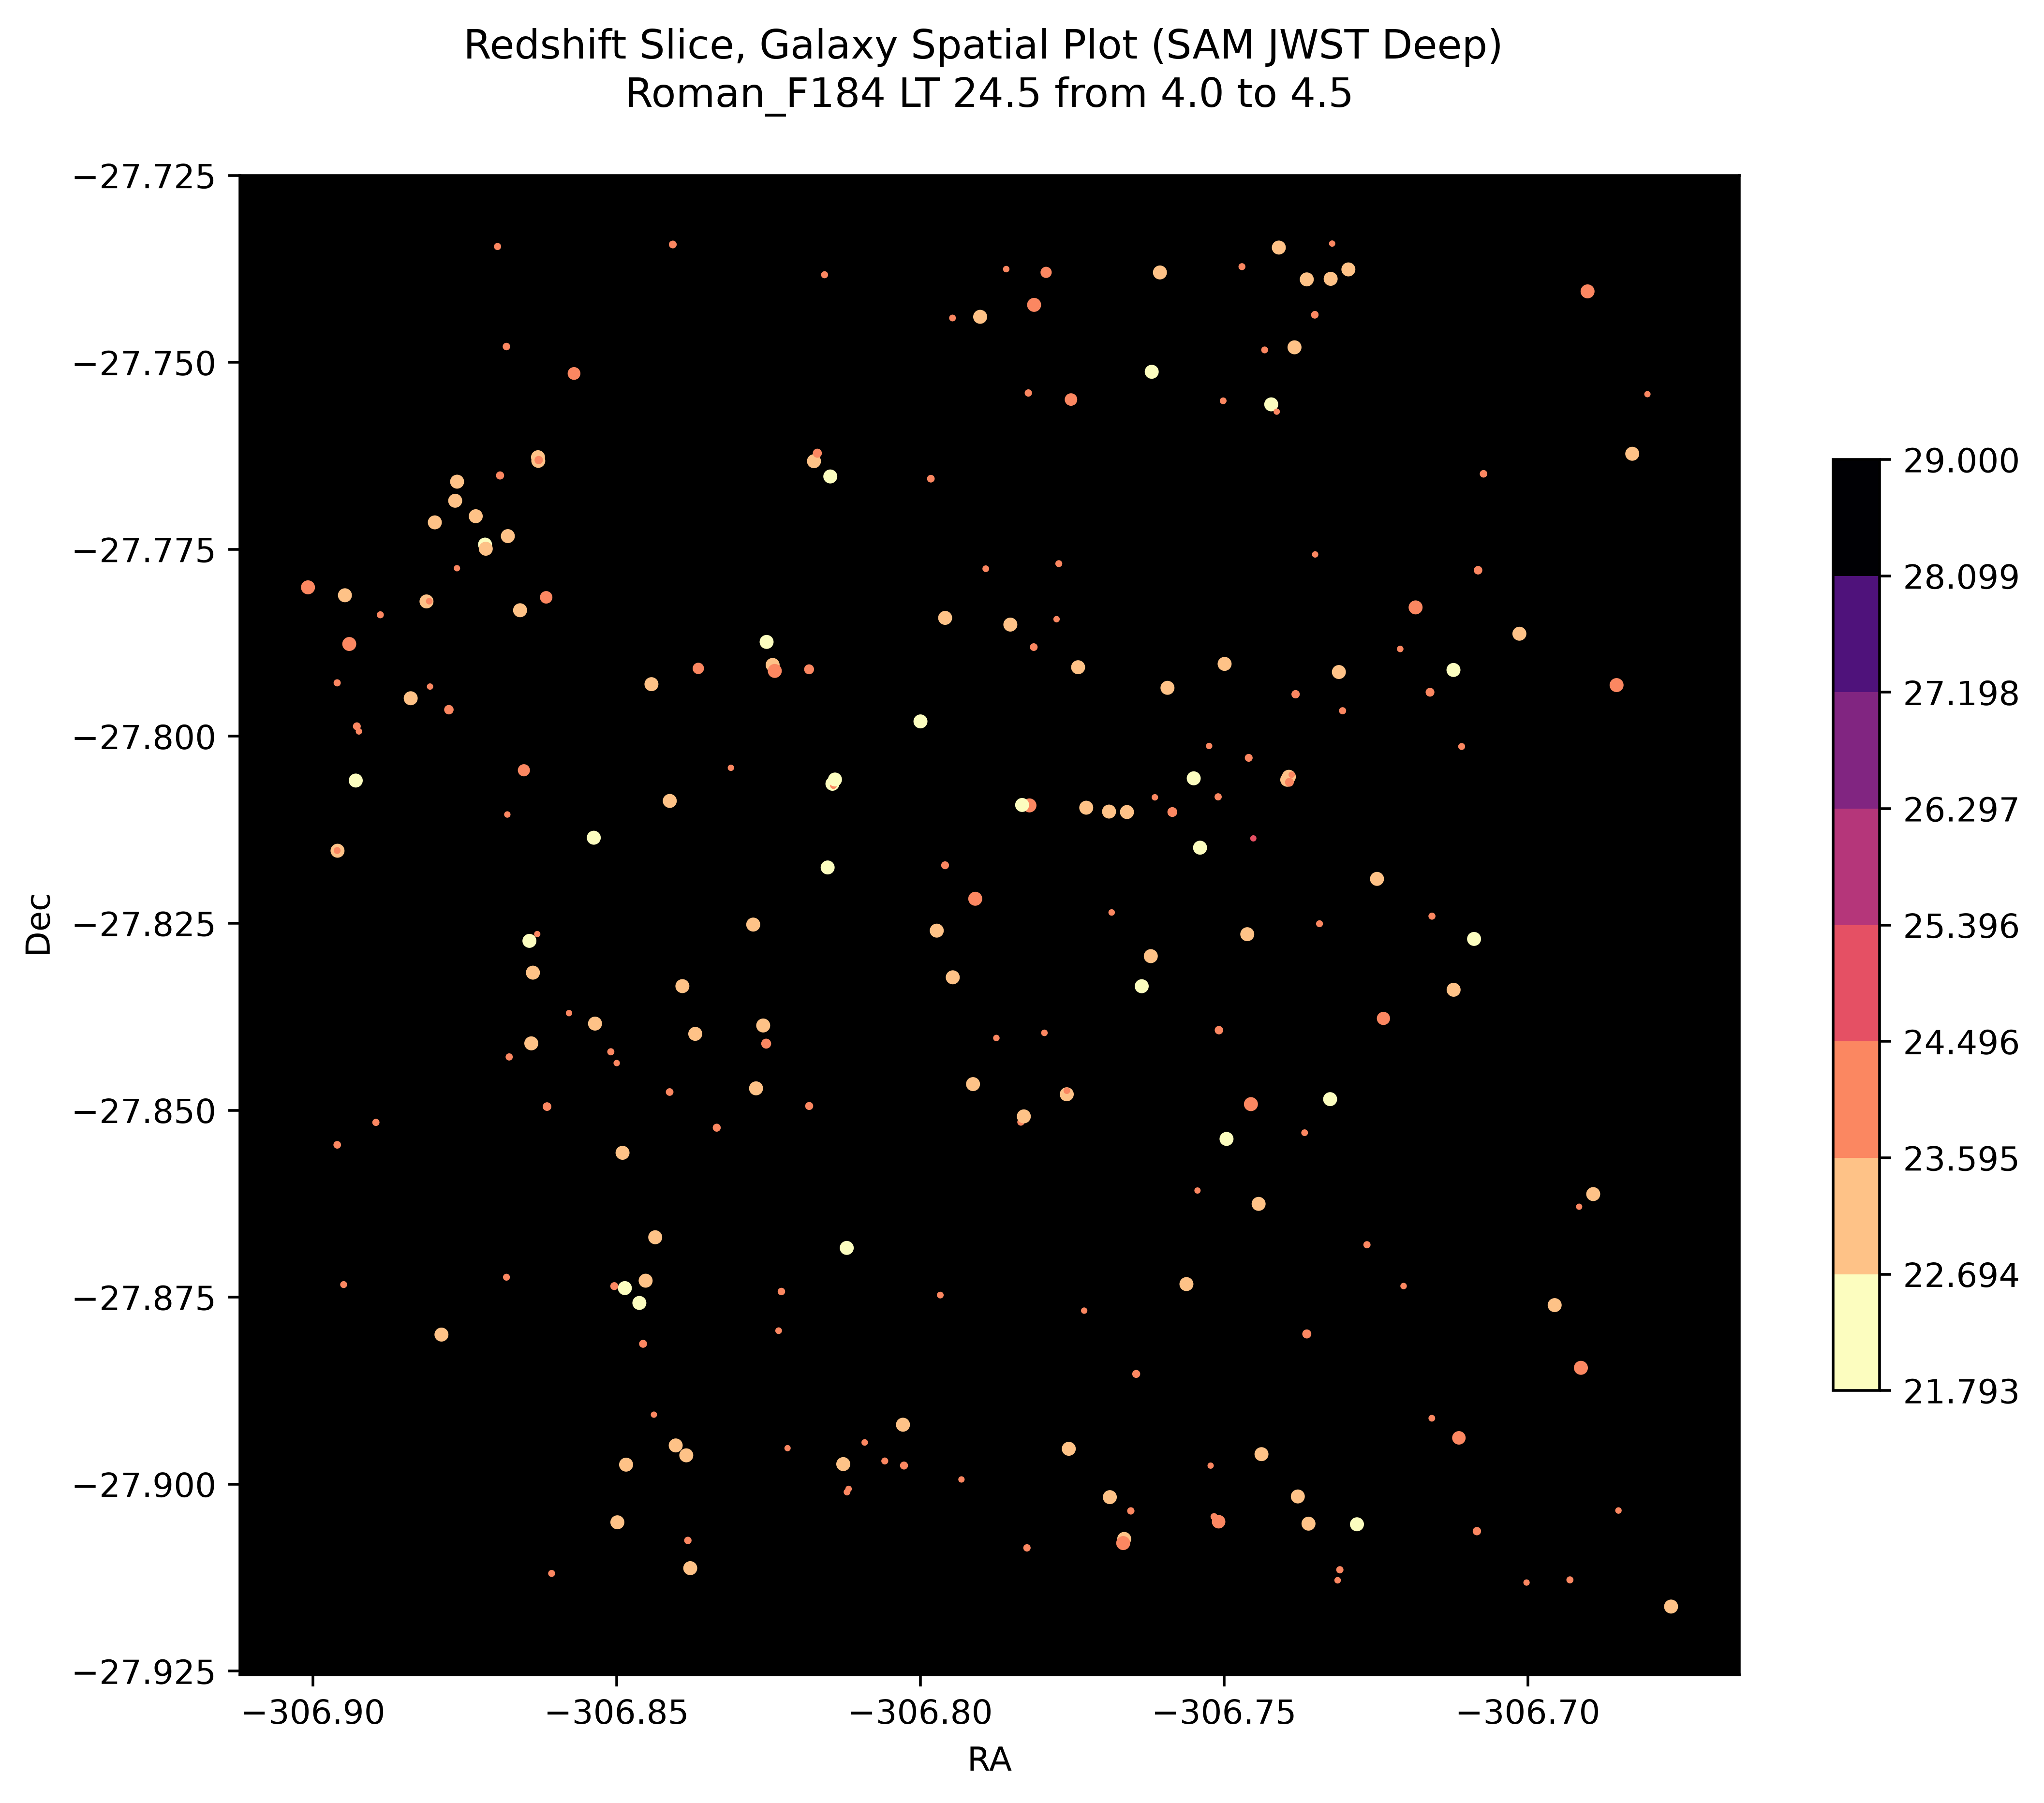

In [80]:
# Plot theses on a scatter plot

fig, ax = plt.subplots(figsize=(10,10))
fig.set_dpi(500)


# configure colorbar
bounds = np.linspace(np.min(thresh_vals),29,9)
cmap = plt.get_cmap("magma_r", len(bounds))
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# make ra/dec scatter plot
radec = ax.scatter(ra_vals, dec_vals, norm=norm, c=thresh_vals, s=size_vals, cmap=cmap)

# add the colorbar
cbar = fig.colorbar(radec, ax=ax, shrink=0.5)


# other subplot settings
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title(f"Redshift Slice, Galaxy Spatial Plot (SAM JWST Deep) \n{config['thresh_var']} {config['thresh_val'][1]} {lim} from {z_min} to {z_max}\n")
ax.set_facecolor('k')
ax.set_box_aspect(1)



In [81]:
# 'mhalo' = mass of sub-halo (at the time it became a sub)
# 'mstar' = stellar mass

## Now we want to plot a histogram of SHMR over Halo mass

varA = 'mstar'
varB = 'mhalo'

# Create two empty lists, SM and HM
sm = []
hm = []

# For every row in the table, add the SM value and HM value to their respective lists
for i in range(len(data)):
    sm.append(data.loc[i, varA])
    hm.append(data.loc[i, varB])

# quick sanity check
print(len(data), len(sm), len(hm), 'these should all be the same')
print('stellar mass: min, max, avg =',np.min(sm), np.max(sm), np.mean(hm))
print('halo mass: min, max, avg =', np.min(hm), np.max(hm), np.mean(hm))


KeyError: 'mstar'

In [ ]:
# define a SHMR list as SM/HM 
shmr = np.array(sm)/ np.array(hm)
print('SHMR: min, max, avg =', np.min(shmr), np.max(shmr), np.mean(shmr))


# create log-scale HM
loghm = np.log10(hm)
print('logHM: min, max, avg =', np.min(loghm), np.max(loghm), np.mean(loghm))

SHMR: min, max, avg = 7.208402657715276e-05 0.10797256712757296 0.002855747093281938
logHM: min, max, avg = -0.23989167183190577 3.155551005577477 0.378248172842581


Text(0.5, 1.0, 'mstar/mhalo over mhalo')

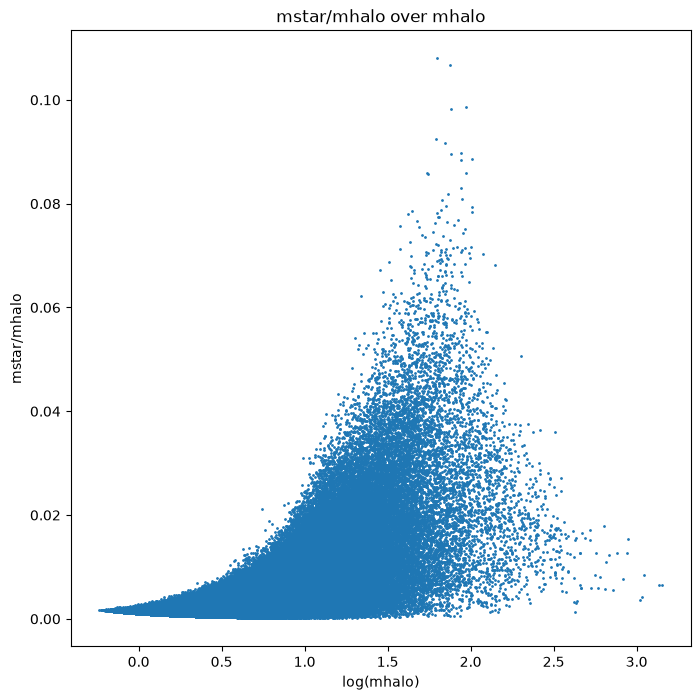

In [ ]:
# Create a mpl figure
fig, ax = plt.subplots(figsize=(8,8))

# Create a histogram object of SHMR and HM 
hist = ax.scatter(loghm,shmr, s=1)
ax.set_xlabel(f'log({varB})')
ax.set_ylabel(varA+'/'+varB)
ax.set_title(f"{varA}/{varB} over {varB}")

In [ ]:
colnames = data.columns
for i in range(len(colnames)):
    if 'halo' in colnames[i]:
        print(colnames[i])



halo_id_nbody
m_hot_halo
Z_hot_halo
mhalo
